In [1]:
#Lab Exercise 2

In [2]:
#Reg no: 2648551

In [3]:
#Name: Vijaya Kerketta

In [4]:
#Part A: Dataset Understanding

In [5]:
#Q1) The domain of my dataset is Environment.

In [6]:
#Q2)
#Categorical attributes: City, date ,AQI_Bucket
# Continuous attributes: PM2.5 , PM10, NO, NO2, NOx, NH3, CO, SO2, O3, Benzene, Toluene , Xylene , AQI


In [7]:
#Q3) 
#For the given dataset , there are some categorical values as well as continuous values. Some of the continuous values range high while some range low. 
#For all the attributes to contribute equally in gthe dataset , and make sure there is no biasedness in the model , we perform normalization in the 
#given dataset

In [8]:
#Part B: Data Preparation

In [9]:
#Q1) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df=pd.read_csv("C:/Users/Msi/Desktop/vij/city_day.csv")
df
print("Information")
print(df.info())
print("Statistical summary")
print(df.describe())

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None
Statistical summary
              PM2.5          PM10            NO           NO2  

sum of missing values before data cleaning :
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


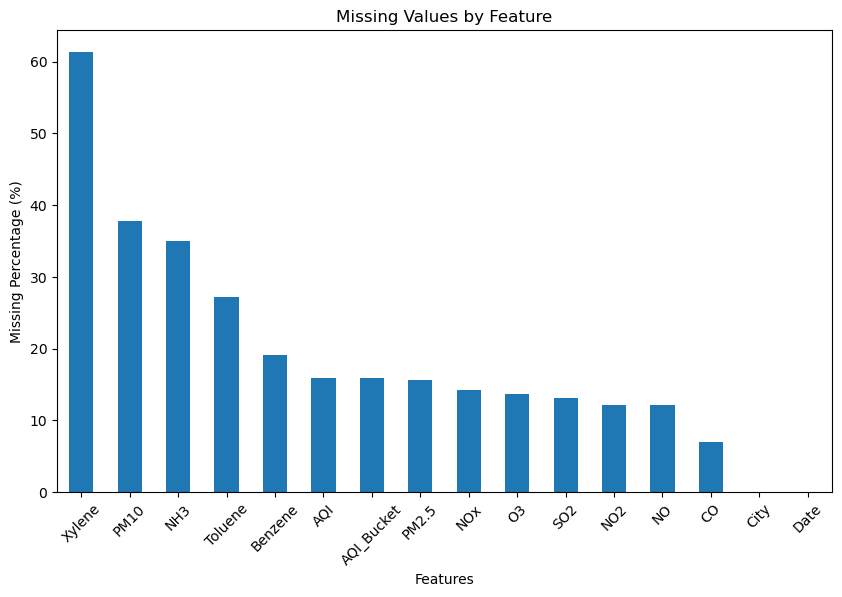

In [10]:
#Q2)
print("sum of missing values before data cleaning :")
print(df.isnull().sum())

# Missing values percentage
missing_pct = (df.isnull().sum() / len(df)) * 100

# Plot
pl.figure(figsize=(10,6))
missing_pct.sort_values(ascending=False).plot(kind='bar')
pl.ylabel('Missing Percentage (%)')
pl.xlabel('Features')
pl.title('Missing Values by Feature')
pl.xticks(rotation=45)
pl.show()

In [11]:
df.drop('Xylene', axis=1, inplace=True)
print(df)

                City        Date  PM2.5   PM10     NO    NO2    NOx    NH3  \
0          Ahmedabad  2015-01-01    NaN    NaN   0.92  18.22  17.15    NaN   
1          Ahmedabad  2015-01-02    NaN    NaN   0.97  15.69  16.46    NaN   
2          Ahmedabad  2015-01-03    NaN    NaN  17.40  19.30  29.70    NaN   
3          Ahmedabad  2015-01-04    NaN    NaN   1.70  18.48  17.97    NaN   
4          Ahmedabad  2015-01-05    NaN    NaN  22.10  21.42  37.76    NaN   
...              ...         ...    ...    ...    ...    ...    ...    ...   
29526  Visakhapatnam  2020-06-27  15.02  50.94   7.68  25.06  19.54  12.47   
29527  Visakhapatnam  2020-06-28  24.38  74.09   3.42  26.06  16.53  11.99   
29528  Visakhapatnam  2020-06-29  22.91  65.73   3.45  29.53  18.33  10.71   
29529  Visakhapatnam  2020-06-30  16.64  49.97   4.05  29.26  18.80  10.03   
29530  Visakhapatnam  2020-07-01  15.00  66.00   0.40  26.85  14.05   5.20   

          CO    SO2      O3  Benzene  Toluene   AQI    AQI_Buck

In [12]:
print("Sum of missing values after data cleaning: ")
cat_cols=['AQI_Bucket']
num_cols=['PM2.5' , 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene' , 'AQI']
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.isnull().sum())

Sum of missing values after data cleaning: 
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


C:\Users\Msi\AppData\Local\Temp\ipykernel_14980\283658559.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Msi\AppData\Local\Temp\ipykernel_14980\283658559.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [13]:
print(df.drop_duplicates())

                City        Date  PM2.5   PM10     NO    NO2    NOx    NH3  \
0          Ahmedabad  2015-01-01  48.57  95.68   0.92  18.22  17.15  15.85   
1          Ahmedabad  2015-01-02  48.57  95.68   0.97  15.69  16.46  15.85   
2          Ahmedabad  2015-01-03  48.57  95.68  17.40  19.30  29.70  15.85   
3          Ahmedabad  2015-01-04  48.57  95.68   1.70  18.48  17.97  15.85   
4          Ahmedabad  2015-01-05  48.57  95.68  22.10  21.42  37.76  15.85   
...              ...         ...    ...    ...    ...    ...    ...    ...   
29526  Visakhapatnam  2020-06-27  15.02  50.94   7.68  25.06  19.54  12.47   
29527  Visakhapatnam  2020-06-28  24.38  74.09   3.42  26.06  16.53  11.99   
29528  Visakhapatnam  2020-06-29  22.91  65.73   3.45  29.53  18.33  10.71   
29529  Visakhapatnam  2020-06-30  16.64  49.97   4.05  29.26  18.80  10.03   
29530  Visakhapatnam  2020-07-01  15.00  66.00   0.40  26.85  14.05   5.20   

          CO    SO2      O3  Benzene  Toluene    AQI    AQI_Buc

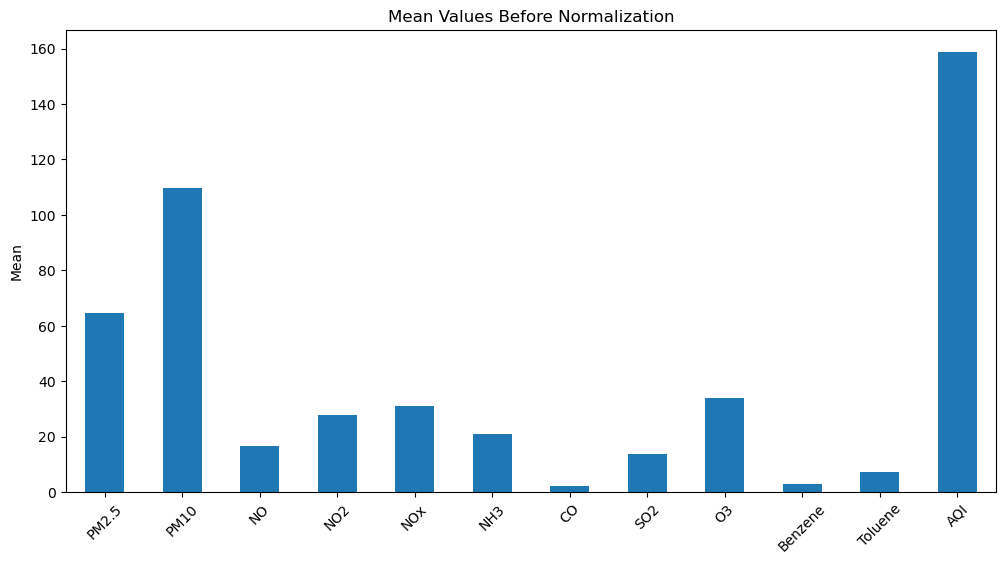

In [14]:
pl.figure(figsize=(12,6))
df[num_cols].mean().plot(kind='bar')
pl.title('Mean Values Before Normalization')
pl.ylabel('Mean')
pl.xticks(rotation=45)
pl.show()

<Figure size 1200x600 with 0 Axes>

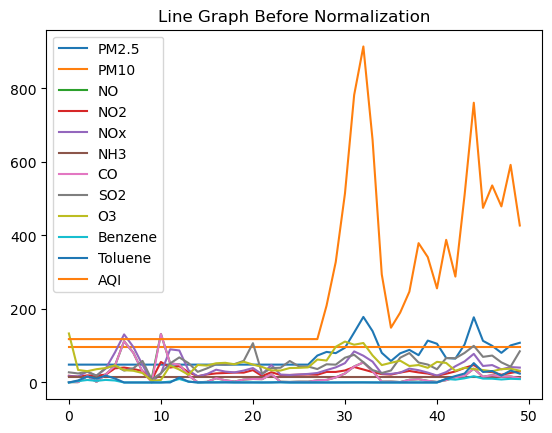

In [15]:
pl.figure(figsize=(12,6))
df[num_cols].head(50).plot()
pl.title('Line Graph Before Normalization')
pl.show()

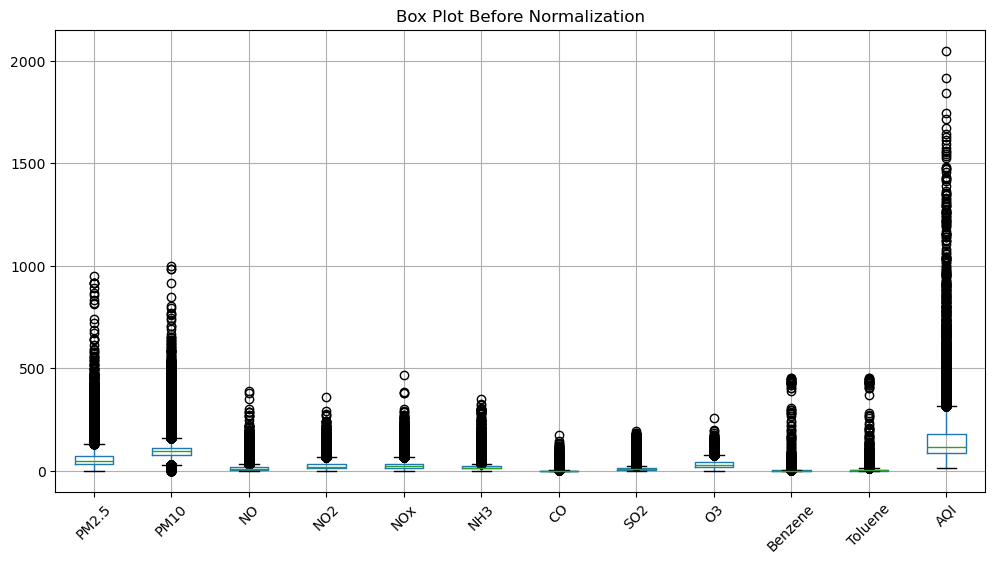

In [16]:
pl.figure(figsize=(12,6))
df[num_cols].boxplot(rot=45)
pl.title('Box Plot Before Normalization')
pl.show()

In [17]:
# IQR Outlier Treatment
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

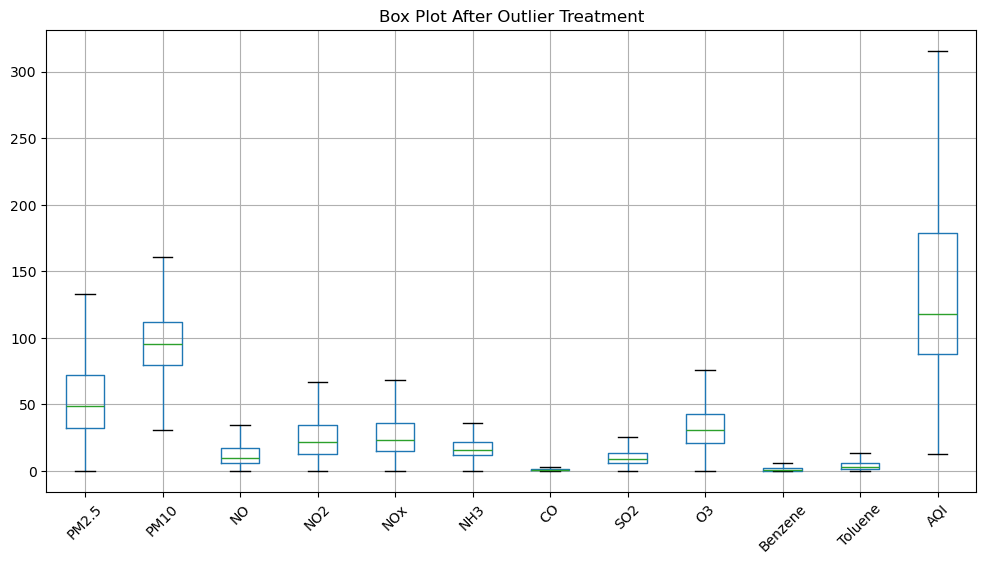

In [18]:
pl.figure(figsize=(12,6))
df[num_cols].boxplot(rot=45)
pl.title("Box Plot After Outlier Treatment")
pl.show()

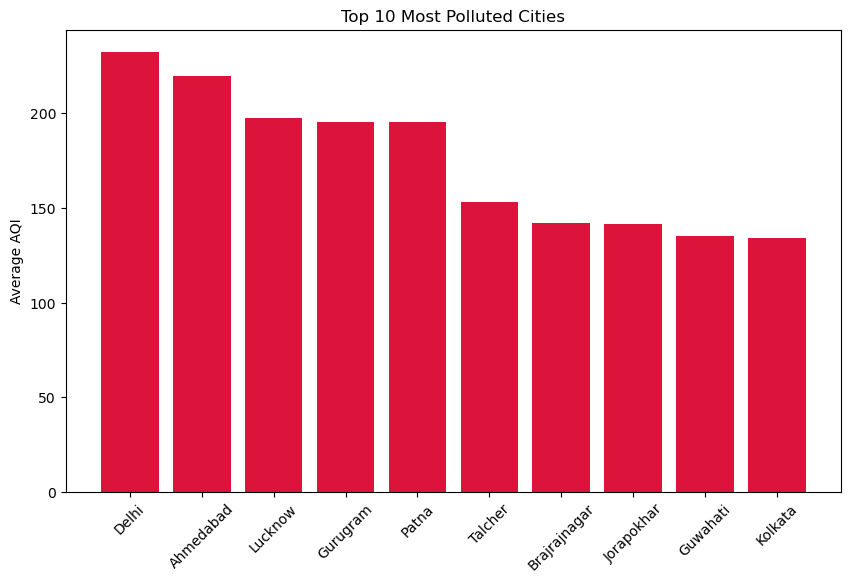

In [30]:
top10 = (
    df.groupby('City')['AQI']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

pl.figure(figsize=(10,6))
pl.bar(top10.index, top10.values, color='crimson')
pl.xticks(rotation=45)
pl.ylabel('Average AQI')
pl.title('Top 10 Most Polluted Cities')
pl.show()

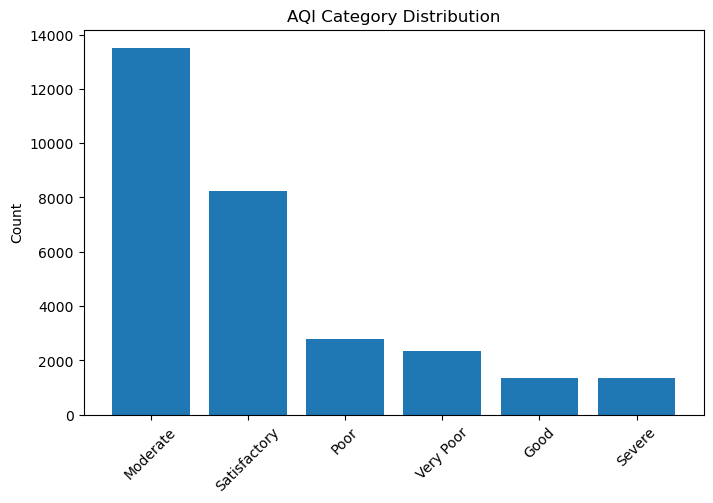

In [31]:
bucket_counts = df['AQI_Bucket'].value_counts()

pl.figure(figsize=(8,5))
pl.bar(bucket_counts.index, bucket_counts.values)
pl.xticks(rotation=45)
pl.ylabel('Count')
pl.title('AQI Category Distribution')
pl.show()

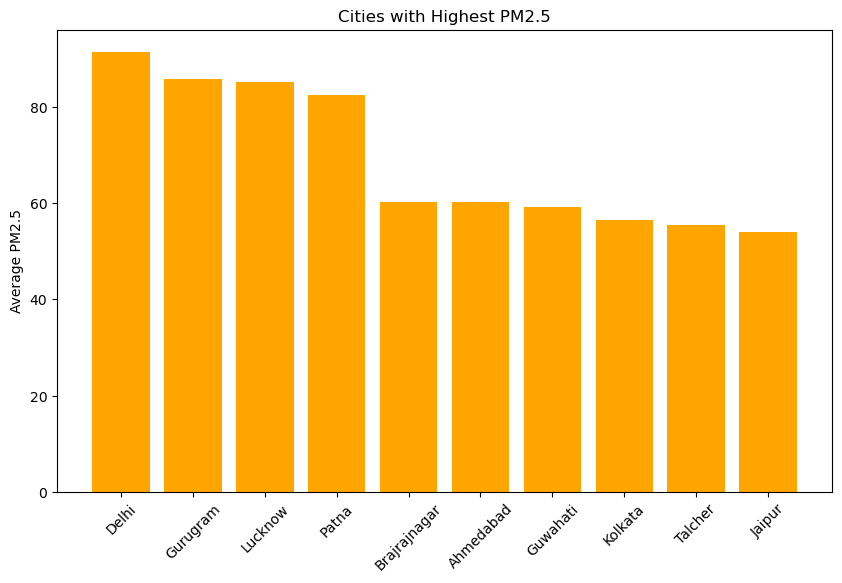

In [32]:
top_pm25 = (
    df.groupby('City')['PM2.5']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

pl.figure(figsize=(10,6))
pl.bar(top_pm25.index, top_pm25.values, color='orange')
pl.xticks(rotation=45)
pl.ylabel('Average PM2.5')
pl.title('Cities with Highest PM2.5')
pl.show()

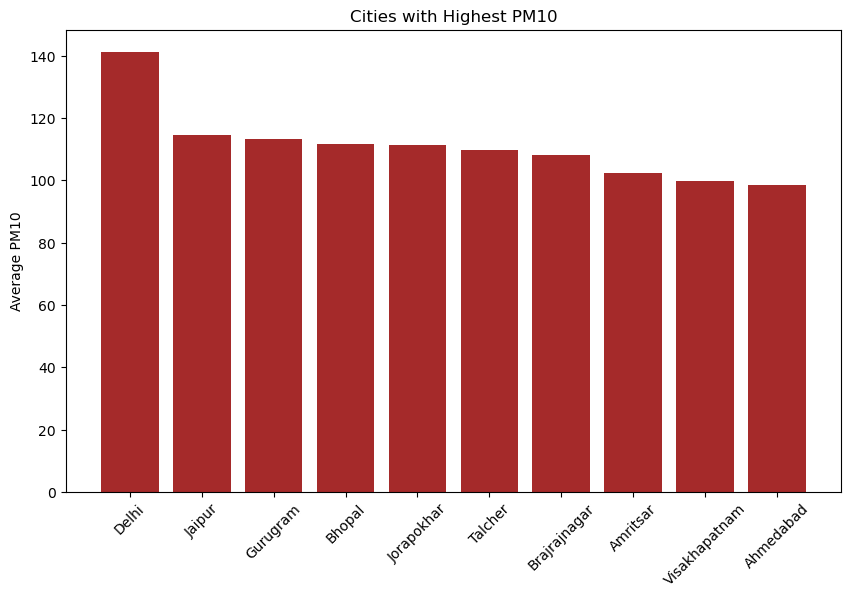

In [33]:
top_pm10 = (
    df.groupby('City')['PM10']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

pl.figure(figsize=(10,6))
pl.bar(top_pm10.index, top_pm10.values, color='brown')
pl.xticks(rotation=45)
pl.ylabel('Average PM10')
pl.title('Cities with Highest PM10')
pl.show()

In [19]:
#PART C
#Q1
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax.fit_transform(df[num_cols])
print(df_minmax.head())

        City        Date     PM2.5      PM10        NO       NO2       NOx  \
0  Ahmedabad  2015-01-01  0.365272  0.500633  0.026019  0.271053  0.252085   
1  Ahmedabad  2015-01-02  0.365272  0.500633  0.027465  0.233394  0.241943   
2  Ahmedabad  2015-01-03  0.365272  0.500633  0.502457  0.287128  0.436556   
3  Ahmedabad  2015-01-04  0.365272  0.500633  0.048569  0.274923  0.264138   
4  Ahmedabad  2015-01-05  0.365272  0.500633  0.638335  0.318684  0.555029   

        NH3        CO       SO2        O3   Benzene   Toluene       AQI  \
0  0.436153  0.348485  1.000000  1.000000  0.000000  0.001523  0.347107   
1  0.436153  0.367424  0.966903  0.449772  0.646749  0.418888  0.347107   
2  0.436153  1.000000  1.000000  0.405389  1.000000  1.000000  0.347107   
3  0.436153  0.643939  0.732072  0.476455  0.778559  0.772277  0.347107   
4  0.436153  1.000000  1.000000  0.519120  1.000000  1.000000  0.347107   

  AQI_Bucket  
0   Moderate  
1   Moderate  
2   Moderate  
3   Moderate  
4   M

In [20]:
comparison = pd.DataFrame({
    'Original_PM2.5': df['PM2.5'].head(),
    'MinMax_PM2.5': df_minmax['PM2.5'].head()
})

print(comparison)

   Original_PM2.5  MinMax_PM2.5
0           48.57      0.365272
1           48.57      0.365272
2           48.57      0.365272
3           48.57      0.365272
4           48.57      0.365272


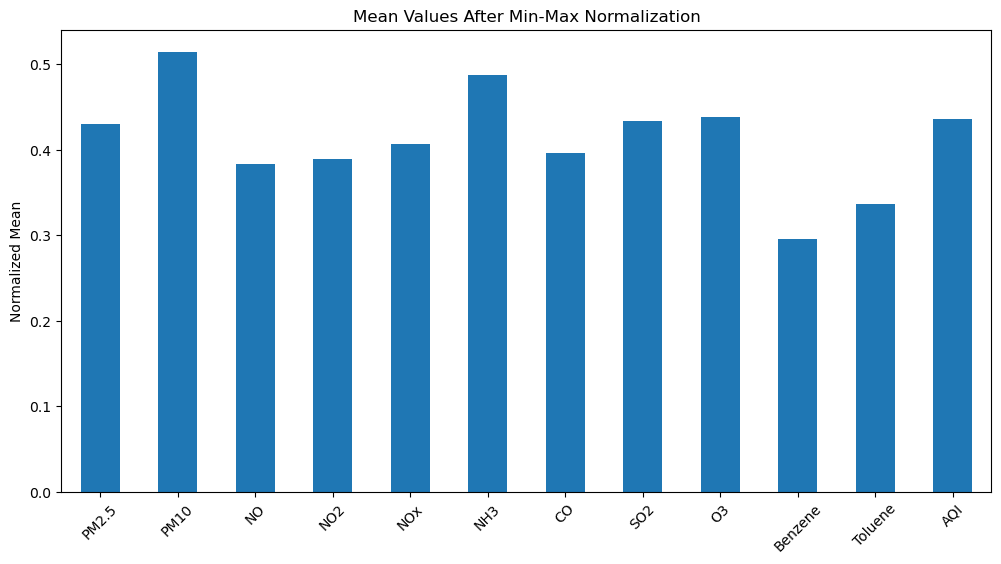

In [21]:
pl.figure(figsize=(12,6))
df_minmax[num_cols].mean().plot(kind='bar')
pl.title('Mean Values After Min-Max Normalization')
pl.ylabel('Normalized Mean')
pl.xticks(rotation=45)
pl.show()

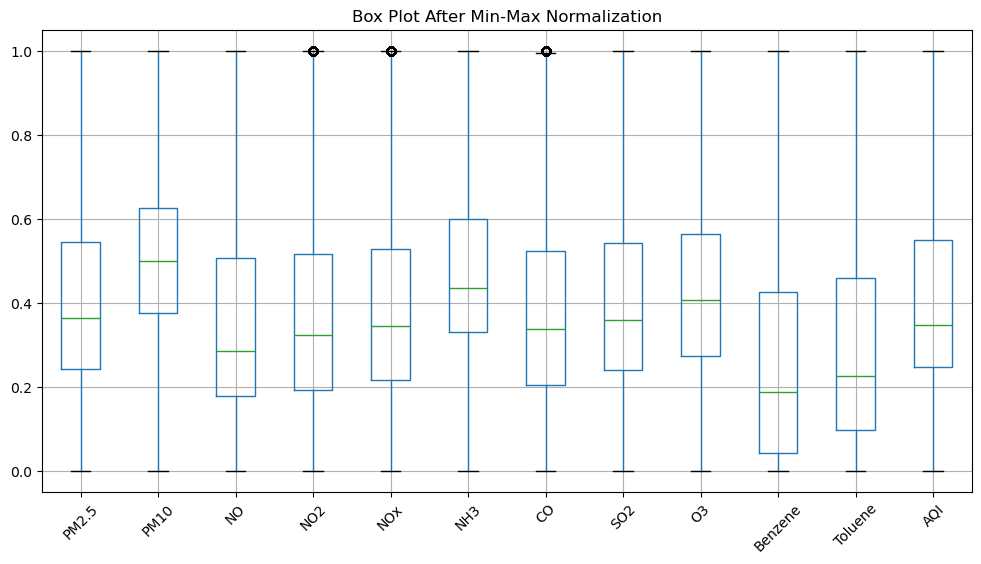

In [22]:
pl.figure(figsize=(12,6))
df_minmax[num_cols].boxplot(rot=45)
pl.title('Box Plot After Min-Max Normalization')
pl.show()

In [23]:
#Q2
zscore = StandardScaler()
df_zscore = df.copy()
df_zscore[num_cols] = zscore.fit_transform(df[num_cols])
print(df_zscore.head())

        City        Date     PM2.5      PM10        NO       NO2       NOx  \
0  Ahmedabad  2015-01-01 -0.246661 -0.048713 -1.221912 -0.454340 -0.558418   
1  Ahmedabad  2015-01-02 -0.246661 -0.048713 -1.216977 -0.599579 -0.594920   
2  Ahmedabad  2015-01-03 -0.246661 -0.048713  0.404626 -0.392341  0.105484   
3  Ahmedabad  2015-01-04 -0.246661 -0.048713 -1.144927 -0.439414 -0.515040   
4  Ahmedabad  2015-01-05 -0.246661 -0.048713  0.868505 -0.270638  0.531863   

        NH3        CO       SO2        O3   Benzene   Toluene       AQI  \
0 -0.194977 -0.170196  2.108206  2.400896 -0.938243 -1.024301 -0.327402   
1 -0.194977 -0.103140  1.985092  0.047372  1.114182  0.251793 -0.327402   
2 -0.194977  2.136514  2.108206 -0.142470  2.235208  2.028545 -0.327402   
3 -0.194977  0.875870  1.111573  0.161502  1.532476  1.332282 -0.327402   
4 -0.194977  2.136514  2.108206  0.343999  2.235208  2.028545 -0.327402   

  AQI_Bucket  
0   Moderate  
1   Moderate  
2   Moderate  
3   Moderate  
4   M

In [24]:
comparison = pd.DataFrame({
    'Original_PM2.5': df['PM2.5'].head(),
    'MinMax_PM2.5': df_zscore['PM2.5'].head()
})

print(comparison)

   Original_PM2.5  MinMax_PM2.5
0           48.57     -0.246661
1           48.57     -0.246661
2           48.57     -0.246661
3           48.57     -0.246661
4           48.57     -0.246661


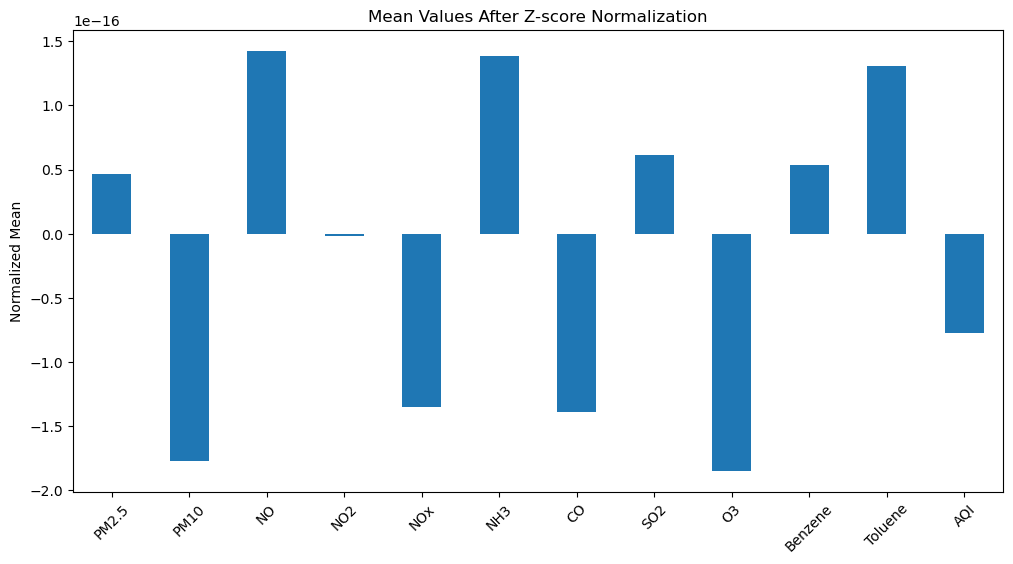

In [25]:
pl.figure(figsize=(12,6))
df_zscore[num_cols].mean().plot(kind='bar')
pl.title('Mean Values After Z-score Normalization')
pl.ylabel('Normalized Mean')
pl.xticks(rotation=45)
pl.show()

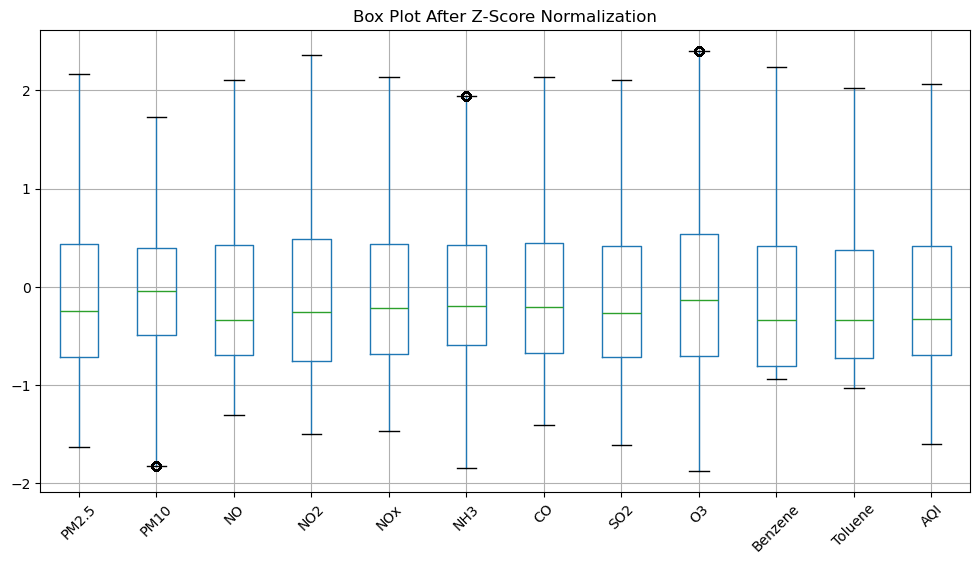

In [26]:
pl.figure(figsize=(12,6))
df_zscore[num_cols].boxplot(rot=45)
pl.title('Box Plot After Z-Score Normalization')
pl.show()

In [27]:
#Part D: Analysis

In [29]:
#Q1
#Min-Max Normalization
#Scales values between 0 and 1.
#Easy to interpret and compare.
#More sensitive to outliers.

#Z-Score Normalization
#Transforms data to mean = 0 and standard deviation = 1.
#Produces a more balanced distribution.
#Less affected by extreme values.
#Min-Max provides a fixed range, while Z-Score standardizes the data around its mean and spread.

In [ ]:
#Q2
#Z-Score Normalization is the most suitable method for the AQI dataset. Air quality parameters such as PM2.5, PM10, NO₂, SO₂, CO, and O₃ 
#have different units and ranges. Z-Score normalization standardizes these variables by considering their mean and standard deviation, 
#resulting in a balanced dataset.
#The box plots after Z-Score normalization showed a more uniform spread of values compared to Min-Max normalization. This makes the data
#more suitable for statistical analysis and machine learning models.